# Steps:
1. Data collection and preprocessing.
2. Time series analysis (trends, seasonality, stationarity).
3. Data preparation for GRU modeling.
4. Building and training the GRU model in PyTorch.
5. Evaluating the model and forecasting.

In [26]:
import yfinance as yf #fetch the historical stock market data from yahoo finance; use to fetch the data 
import pandas as pd  #data manipulation and analysis ( It simplifies handling tabular data)

stocks = ['AMZN', 'IBM', 'MSFT'] #only 3 companies to be fetch data
data = {}  

#download the stocks data from yf api 
for stock in stocks:
    data[stock] = yf.download(stock, start='2015-01-01', end='2025-04-29')['Close']

# Combines the closing prices of all stocks into a single DataFrame.
df = pd.concat(data, axis=1)
df.columns = stocks  #Rename the column
df.to_csv('stock_prices.csv') #exporting to CSV

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


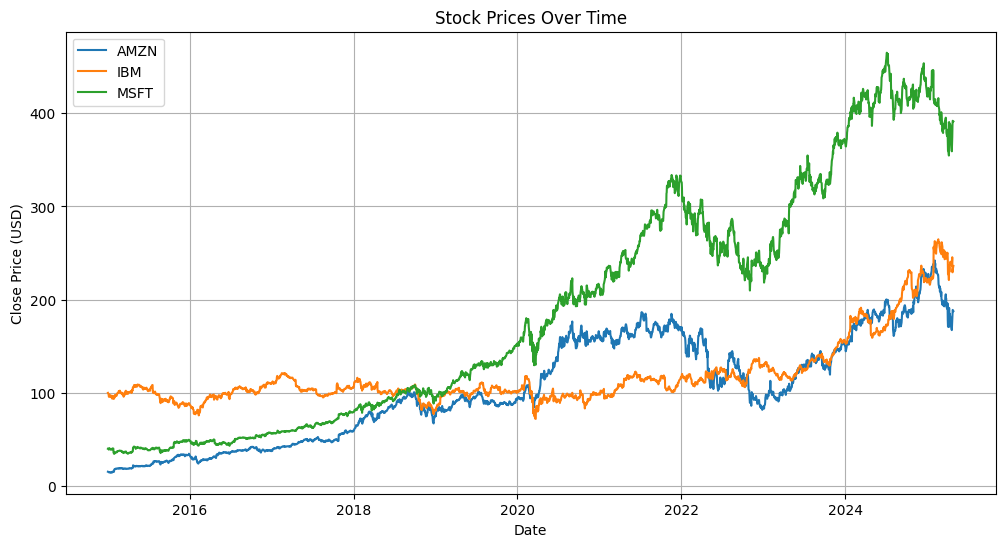

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for stock in stocks:
    plt.plot(df[stock], label=stock)
plt.title('Stock Prices Over Time')
plt.xlabel('Date')
plt.grid(True)
plt.ylabel('Close Price (USD)')
plt.legend()
plt.show()

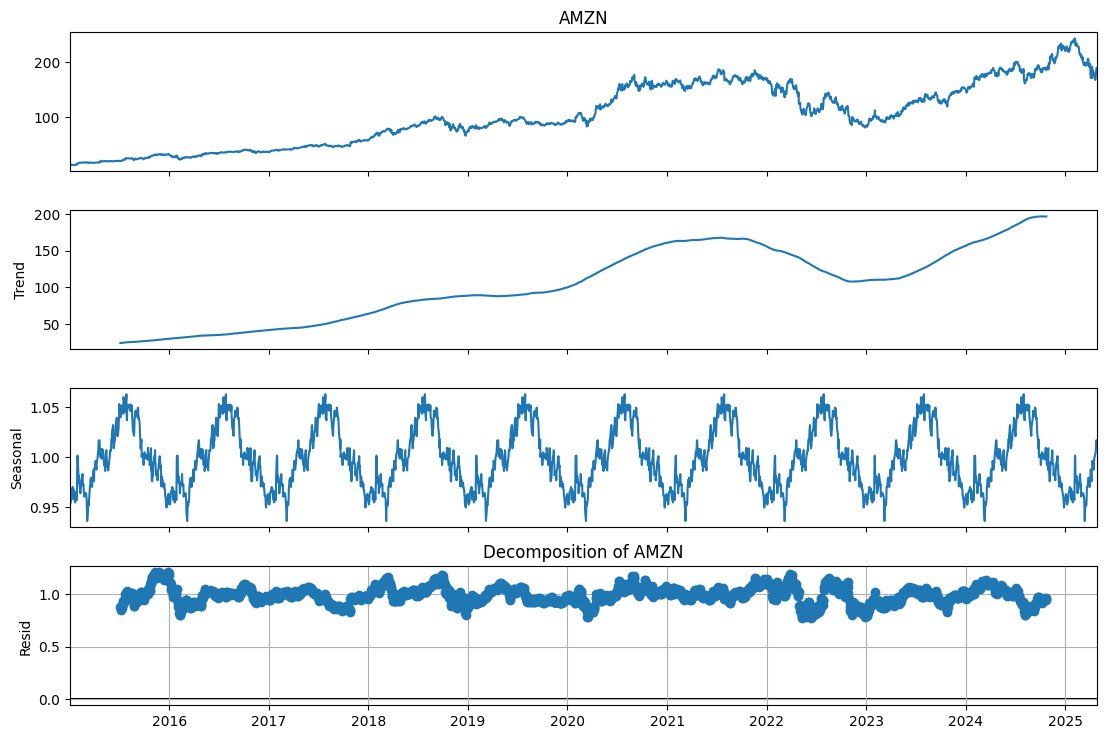

AMZN Trend Component:
Date
2015-07-06    23.939501
2015-07-07    24.004984
2015-07-08    24.071349
2015-07-09    24.135524
2015-07-10    24.196646
Name: trend, dtype: float64

AMZN Seasonal Component:
Date
2015-01-02    0.952844
2015-01-05    0.955414
2015-01-06    0.962903
2015-01-07    0.965390
2015-01-08    0.965453
Name: seasonal, dtype: float64

AMZN Residual Component:
Date
2015-07-06    0.876253
2015-07-07    0.871269
2015-07-08    0.851792
2015-07-09    0.856457
2015-07-10    0.872551
Name: resid, dtype: float64


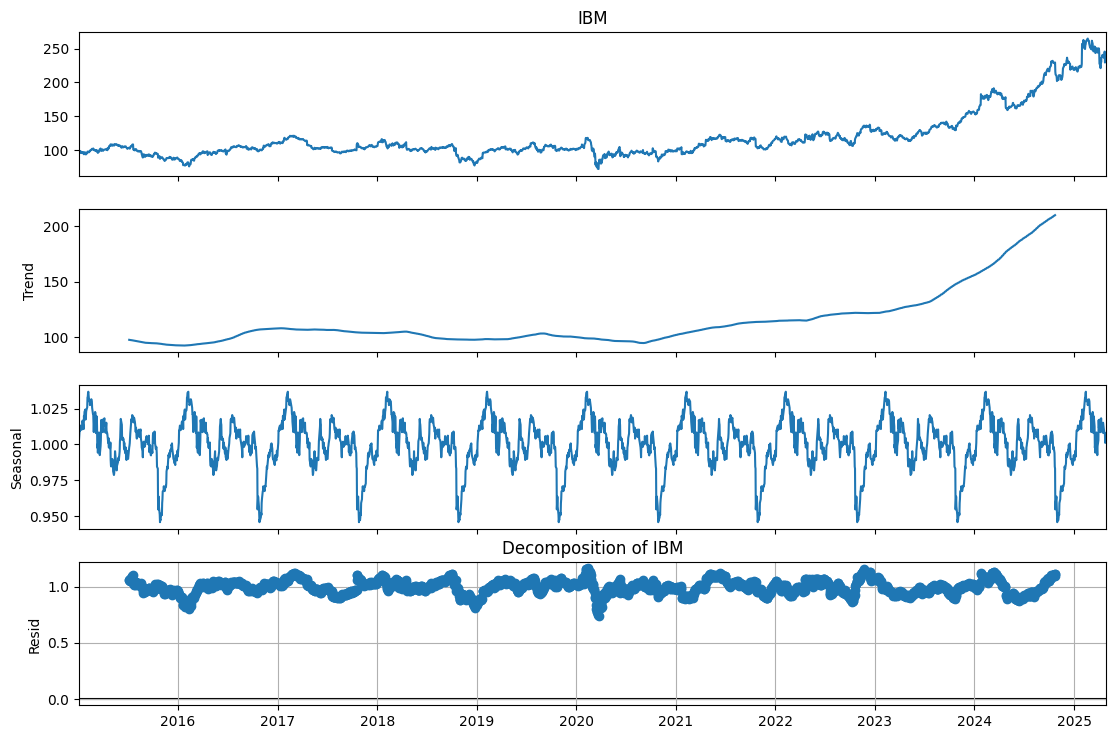

IBM Trend Component:
Date
2015-07-06    97.337505
2015-07-07    97.287441
2015-07-08    97.243725
2015-07-09    97.201688
2015-07-10    97.152299
Name: trend, dtype: float64

IBM Seasonal Component:
Date
2015-01-02    1.001042
2015-01-05    1.009647
2015-01-06    1.009369
2015-01-07    1.011406
2015-01-08    1.013132
Name: seasonal, dtype: float64

IBM Residual Component:
Date
2015-07-06    1.061704
2015-07-07    1.062729
2015-07-08    1.049541
2015-07-09    1.050681
2015-07-10    1.067689
Name: resid, dtype: float64


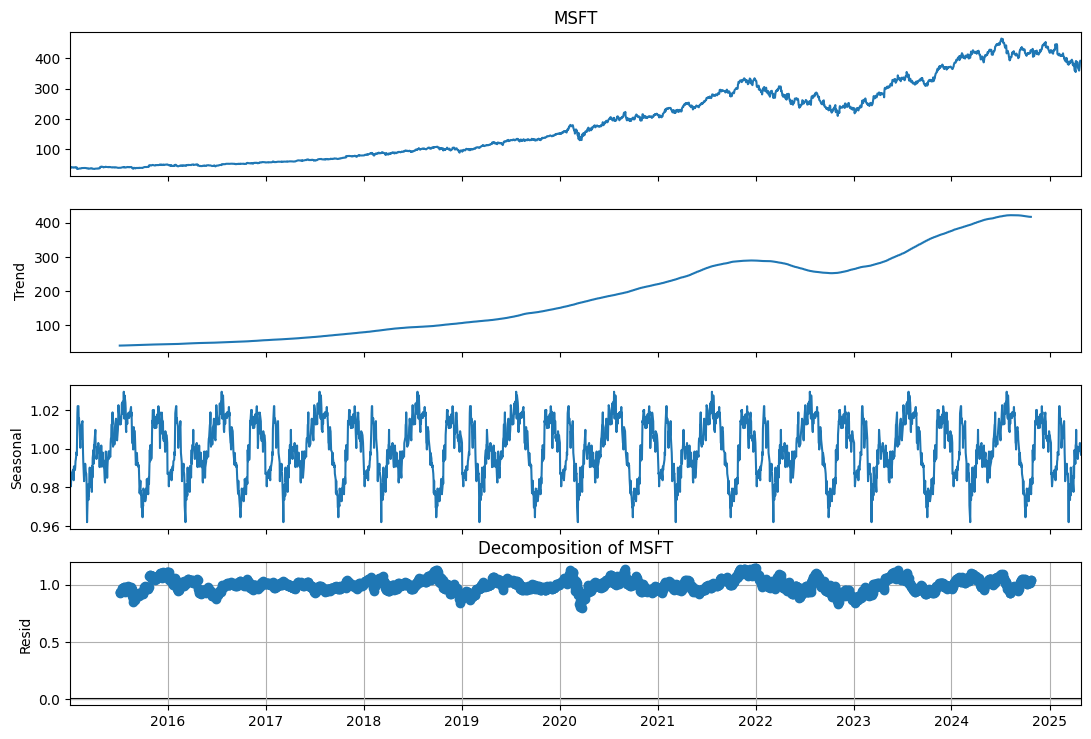

MSFT Trend Component:
Date
2015-07-06    40.618807
2015-07-07    40.652389
2015-07-08    40.686550
2015-07-09    40.715849
2015-07-10    40.738846
Name: trend, dtype: float64

MSFT Seasonal Component:
Date
2015-01-02    0.987556
2015-01-05    0.980524
2015-01-06    0.986057
2015-01-07    0.986702
2015-01-08    0.987376
Name: seasonal, dtype: float64

MSFT Residual Component:
Date
2015-07-06    0.935939
2015-07-07    0.934931
2015-07-08    0.930197
2015-07-09    0.935483
2015-07-10    0.939305
Name: resid, dtype: float64


In [28]:
from statsmodels.tsa.seasonal import seasonal_decompose

for stock in stocks:
    decomposition = seasonal_decompose(df[stock], model='multiplicative', period=252)  # Approx. trading days in a year
    
    # Extract components
    trend = decomposition.trend
    seasonal = decomposition.seasonal
    residual = decomposition.resid
    
    # Plot the decomposition
    fig = decomposition.plot()
    fig.set_size_inches(12, 8)
    plt.grid(True)
    plt.title(f'Decomposition of {stock}')
    plt.show()
    
    # Display components
    print(f'{stock} Trend Component:')
    print(trend.dropna().head())
    print(f'\n{stock} Seasonal Component:')
    print(seasonal.dropna().head())
    print(f'\n{stock} Residual Component:')
    print(residual.dropna().head())

In [29]:
from statsmodels.tsa.stattools import adfuller

for stock in stocks:
    result = adfuller(df[stock].dropna())
    print(f'{stock} ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    if result[1] > 0.05:
        print(f'{stock} is non-stationary. Consider differencing.')
    else:
        print(f'{stock} is stationary.')

AMZN ADF Statistic: -1.1544476564916775
p-value: 0.6928780533595754
AMZN is non-stationary. Consider differencing.
IBM ADF Statistic: 1.1077993310098266
p-value: 0.9952826400655019
IBM is non-stationary. Consider differencing.
MSFT ADF Statistic: -0.2037159951065135
p-value: 0.9380772287803522
MSFT is non-stationary. Consider differencing.


In [30]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = {}
for stock in stocks:
    scaled_data[stock] = scaler.fit_transform(df[stock].values.reshape(-1, 1))

In [31]:
import numpy as np

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

seq_length = 60
X, y = {}, {}
for stock in stocks:
    X[stock], y[stock] = create_sequences(scaled_data[stock], seq_length)

In [32]:
train_size = int(len(X[stocks[0]]) * 0.8)
X_train, X_test, y_train, y_test = {}, {}, {}, {}
for stock in stocks:
    X_train[stock] = X[stock][:train_size]
    X_test[stock] = X[stock][train_size:]
    y_train[stock] = y[stock][:train_size]
    y_test[stock] = y[stock][train_size:]

In [33]:
import torch

for stock in stocks:
    X_train[stock] = torch.FloatTensor(X_train[stock])
    X_test[stock] = torch.FloatTensor(X_test[stock])
    y_train[stock] = torch.FloatTensor(y_train[stock])
    y_test[stock] = torch.FloatTensor(y_test[stock])

In [34]:
import torch.nn as nn

class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_size=1):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

In [35]:
def train_model(model, X_train, y_train, X_test, y_test, epochs=50, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train.to(device))
        loss = criterion(outputs, y_train.to(device))
        loss.backward()
        optimizer.step()
        
        # Validation
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test.to(device))
            test_loss = criterion(test_outputs, y_test.to(device))
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}')
    
    return model

# Train a model for each stock
models = {}
for stock in stocks:
    model = GRUModel()
    print(f'\nTraining model for {stock}...')
    models[stock] = train_model(model, X_train[stock], y_train[stock], X_test[stock], y_test[stock])


Training model for AMZN...
Epoch [10/50], Train Loss: 0.0357, Test Loss: 0.0578
Epoch [20/50], Train Loss: 0.0308, Test Loss: 0.0900
Epoch [30/50], Train Loss: 0.0274, Test Loss: 0.0959
Epoch [40/50], Train Loss: 0.0189, Test Loss: 0.0322
Epoch [50/50], Train Loss: 0.0093, Test Loss: 0.0287

Training model for IBM...
Epoch [10/50], Train Loss: 0.0041, Test Loss: 0.1585
Epoch [20/50], Train Loss: 0.0033, Test Loss: 0.1773
Epoch [30/50], Train Loss: 0.0028, Test Loss: 0.1440
Epoch [40/50], Train Loss: 0.0024, Test Loss: 0.1423
Epoch [50/50], Train Loss: 0.0020, Test Loss: 0.1150

Training model for MSFT...
Epoch [10/50], Train Loss: 0.0375, Test Loss: 0.1705
Epoch [20/50], Train Loss: 0.0238, Test Loss: 0.1894
Epoch [30/50], Train Loss: 0.0106, Test Loss: 0.0584
Epoch [40/50], Train Loss: 0.0006, Test Loss: 0.0004
Epoch [50/50], Train Loss: 0.0006, Test Loss: 0.0003


In [36]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

for stock in stocks:
    model = models[stock]
    model.eval()
    with torch.no_grad():
        predictions = model(X_test[stock]).numpy()
        actual = y_test[stock].numpy()
    
    mse = mean_squared_error(actual, predictions)
    mae = mean_absolute_error(actual, predictions)
    print(f'{stock} - MSE: {mse:.4f}, MAE: {mae:.4f}')

AMZN - MSE: 0.0287, MAE: 0.1563
IBM - MSE: 0.1150, MAE: 0.2949
MSFT - MSE: 0.0003, MAE: 0.0150


In [37]:
def forecast_next_day(model, last_sequence, scaler):
    model.eval()
    with torch.no_grad():
        last_sequence = torch.FloatTensor(last_sequence).unsqueeze(0)
        pred = model(last_sequence).numpy()
        pred = scaler.inverse_transform(pred)
    return pred[0, 0]

for stock in stocks:
    last_sequence = scaled_data[stock][-seq_length:]
    next_price = forecast_next_day(models[stock], last_sequence, scaler)
    print(f'Predicted next day price for {stock}: ${next_price:.2f}')

Predicted next day price for AMZN: $275.65
Predicted next day price for IBM: $174.36
Predicted next day price for MSFT: $383.06


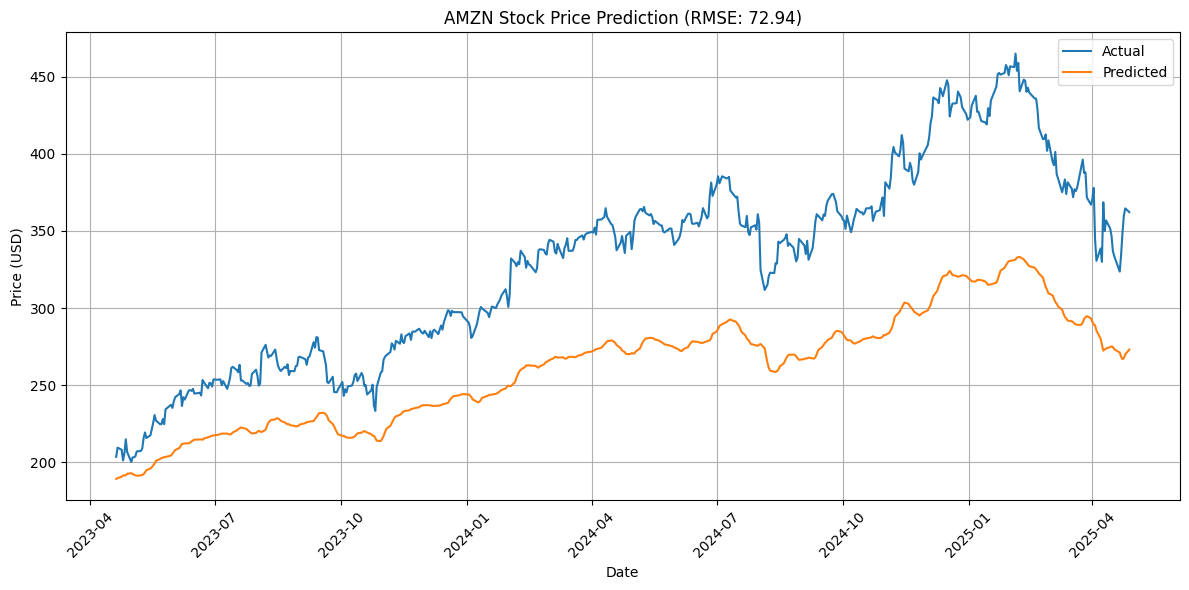

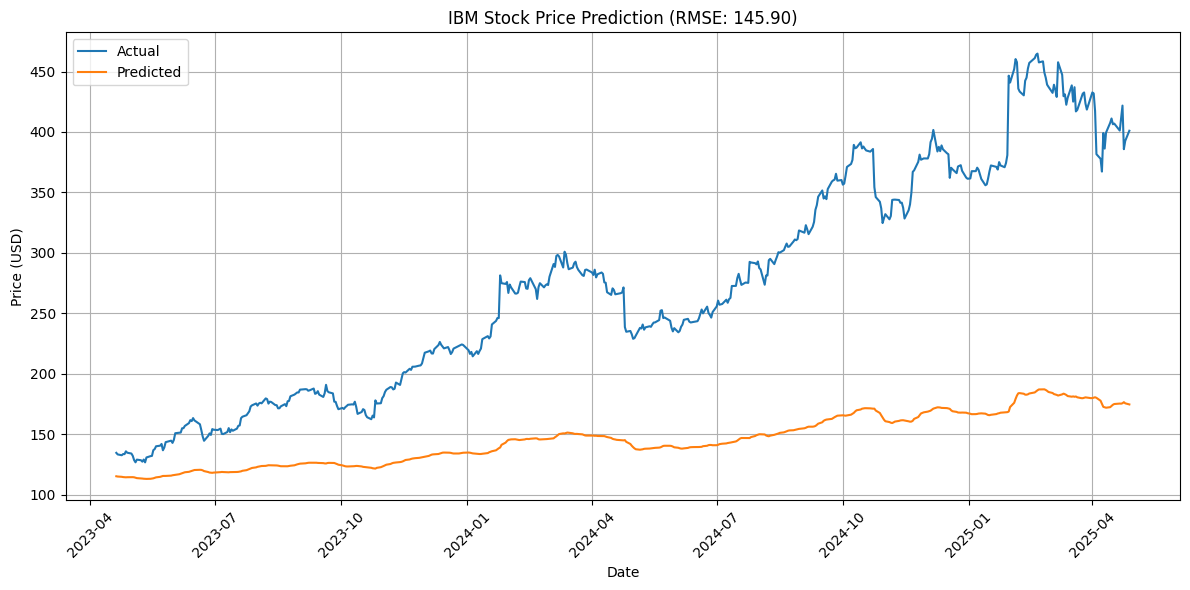

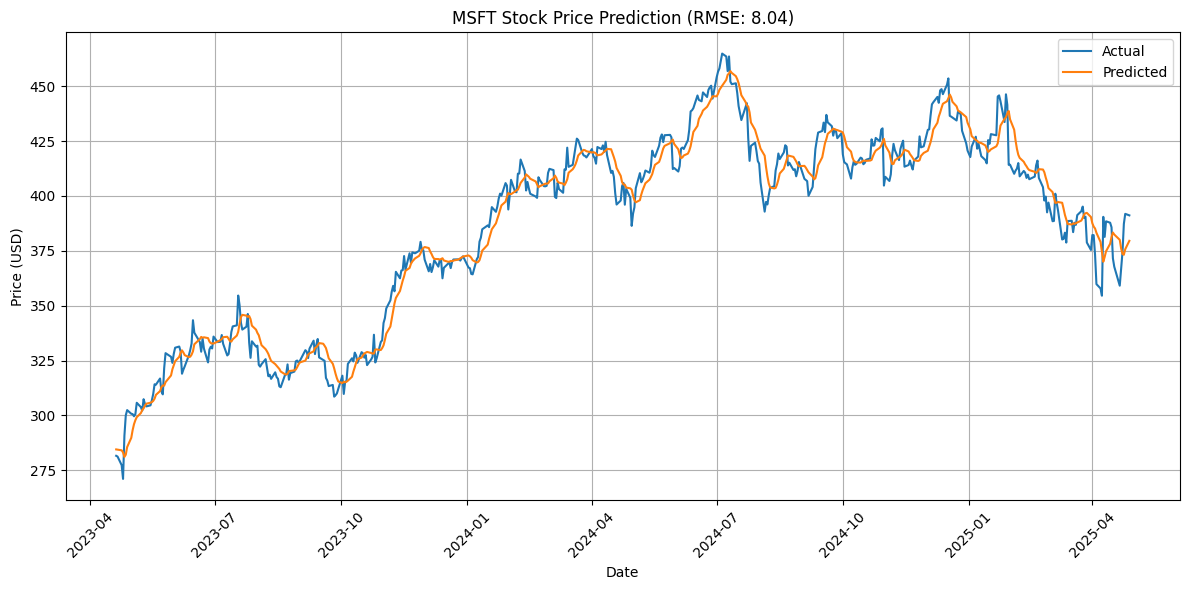

In [38]:
from sklearn.metrics import mean_squared_error
import numpy as np

for stock in stocks:
    model = models[stock]
    model.eval()
    with torch.no_grad():
        pred_scaled = model(X_test[stock]).numpy()
        pred = scaler.inverse_transform(pred_scaled)
        actual = scaler.inverse_transform(y_test[stock].numpy())
    
    rmse = np.sqrt(mean_squared_error(actual, pred))
    
    dates = df.index[-len(actual):]  # Align with actual dates
    
    plt.figure(figsize=(12, 6))
    plt.plot(dates, actual, label='Actual')
    plt.plot(dates, pred, label='Predicted')
    plt.title(f'{stock} Stock Price Prediction (RMSE: {rmse:.2f})')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Accuracy and Performance Metrics for Stock Price Forecasting

In [40]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import torch
import os

# Dictionary to store performance metrics for each stock
metrics = {}

for stock in stocks:
    try:
        model = models[stock]
        model.eval()
        with torch.no_grad():
            # Get predictions and actual values
            pred_scaled = model(X_test[stock]).numpy()
            pred = scaler.inverse_transform(pred_scaled)  # Inverse transform to original scale
            actual = scaler.inverse_transform(y_test[stock].numpy())  # Actual values in original scale

        # Calculate performance metrics
        mse = mean_squared_error(actual, pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(actual, pred)
        r2 = r2_score(actual, pred)

        # Store metrics
        metrics[stock] = {
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2
        }

        # Print metrics
        print(f"\nPerformance Metrics for {stock}")
        print(f"Mean Squared Error (MSE): {mse:.4f}")
        print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
        print(f"Mean Absolute Error (MAE): {mae:.4f}")
        print(f"R² Score: {r2:.4f}")

    except Exception as e:
        print(f"Error processing {stock}: {str(e)}")

# Summary of metrics across all stocks
print("\nSummary of Performance Metrics")
metrics_df = pd.DataFrame(metrics).T
print(metrics_df)

# Save metrics to CSV
metrics_df.to_csv('performance_metrics.csv')
print("Metrics saved to performance_metrics.csv")


Performance Metrics for AMZN
Mean Squared Error (MSE): 5320.2837
Root Mean Squared Error (RMSE): 72.9403
Mean Absolute Error (MAE): 67.2392
R² Score: -0.3265

Performance Metrics for IBM
Mean Squared Error (MSE): 21285.8711
Root Mean Squared Error (RMSE): 145.8968
Mean Absolute Error (MAE): 126.8781
R² Score: -1.4813

Performance Metrics for MSFT
Mean Squared Error (MSE): 64.7134
Root Mean Squared Error (RMSE): 8.0445
Mean Absolute Error (MAE): 6.4742
R² Score: 0.9668

Summary of Performance Metrics
               MSE        RMSE         MAE        R2
AMZN   5320.283691   72.940275   67.239197 -0.326526
IBM   21285.871094  145.896782  126.878143 -1.481258
MSFT     64.713440    8.044466    6.474178  0.966762
Metrics saved to performance_metrics.csv
